In [3]:
import pandas as pd
import requests
from pathlib import Path

In [46]:
project_root = Path.cwd().parent

# Build correct path
raw_data_dir = Path("/workspaces/uk_cost_of_living/data/raw")
raw_data_dir.mkdir(parents=True, exist_ok=True)

In [48]:
fuel_price_url ='https://assets.publishing.service.gov.uk/media/69e640108c9f882ae5997f8c/weekly_road_fuel_prices_200426.csv'
response = requests.get(fuel_price_url)
fuel_output_path = raw_data_dir/"weekly_road_fuel_prices.csv"
with open(fuel_output_path, 'wb') as f:
    f.write(response.content)
df = pd.read_csv(fuel_output_path)


In [68]:
df.shape
df.head()
df.columns
df.describe()
df.isnull().sum()

Date                                                                  0
ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre    0
ULSD (Ultra low sulphur diesel) Pump price in pence/litre             0
ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre     0
ULSD (Ultra low sulphur diesel) Duty rate in pence/litre              0
ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate          0
ULSD (Ultra low sulphur diesel) VAT percentage rate                   0
dtype: int64

In [58]:
csv_url = "https://download.ons.gov.uk/downloads/datasets/cpih01/editions/time-series/versions/67.csv"
response2 = requests.get(csv_url)
cpih_inflation_output_path = raw_data_dir/"cpih_inflation.csv"
with open(cpih_inflation_output_path, 'wb') as f:
    f.write(response2.content)
df2 = pd.read_csv(cpih_inflation_output_path)

In [4]:
df2.isnull().sum()

NameError: name 'df2' is not defined

In [60]:
# Let's see all unique categories
print("📊 All categories:")
print(df2['Aggregate'].unique())

print(f"\nTotal categories: {df2['cpih1dim1aggid'].nunique()}")

# See all unique time periods
print(f"\n📅 Time periods available:")
print(df2['mmm-yy'].unique())

# See overall shape
print(f"\n📐 Shape: {df2.shape}")

📊 All categories:
<StringArray>
[            '05.5 Tools and equipment for house and garden',
           '06.1 Medical products, appliances and equipment',
      '09.2 Other major durables for recreation and culture',
           '09.3 Other recreational items, gardens and pets',
                                     '09.6 Package holidays',
                               '11.2 Accommodation services',
                             '12.3.2 Other personal effects',
                              '01.1.4 Milk, cheese and eggs',
          '05.4 Glassware, tableware and household utensils',
             '01.2.2 Mineral waters, soft drinks and juices',
 ...
                           '07.1.1.2 Second-hand motor cars',
                            '07.2.3 Maintenance and repairs',
                     '07.3.1 Passenger transport by railway',
     '07.3.4 Passenger transport by sea and inland waterway',
                          '09.1.3 Data processing equipment',
                                 

In [61]:
# The overall CPIH aggregate code is 'cpih1dim1A0'
overall_cpih = df2[df2['cpih1dim1aggid'] == 'cpih1dim1A0']

print("📊 Overall CPIH Rate:")
print(overall_cpih.head(10))

📊 Overall CPIH Rate:
Empty DataFrame
Columns: [v4_0, mmm-yy, Time, uk-only, Geography, cpih1dim1aggid, Aggregate]
Index: []


In [62]:
# Search for 'overall' or 'all' in categories
print("🔍 Looking for overall CPIH category:\n")

for cat in df2['Aggregate'].unique():
    if any(word in cat.lower() for word in ['overall', 'all', 'total', 'cpih', 'index']):
        # Also get the code
        code = df2[df2['Aggregate'] == cat]['cpih1dim1aggid'].iloc[0]
        print(f"Category: {cat}")
        print(f"Code: {code}\n")

🔍 Looking for overall CPIH category:

Category: Overall Index
Code: CP00

Category: 05.3.1/2 Major appliances and small electric goods
Code: CP0531_0532



In [63]:
# Filter for overall CPIH index only
overall_cpih = df2[df2['cpih1dim1aggid'] == 'CP00']

print(f"✅ Overall CPIH Data!")
print(f"Shape: {overall_cpih.shape}")
print(f"\nFirst 10 rows:")
print(overall_cpih.head(10))

print(f"\nDate range:")
print(f"Earliest: {overall_cpih['mmm-yy'].iloc[-1]}")
print(f"Latest: {overall_cpih['mmm-yy'].iloc[0]}")

print(f"\nIndex value stats:")
print(overall_cpih['v4_0'].describe())

✅ Overall CPIH Data!
Shape: (457, 7)

First 10 rows:
       v4_0  mmm-yy    Time    uk-only       Geography cpih1dim1aggid  \
86    139.4  Jan-26  Jan-26  K02000001  United Kingdom           CP00   
166   139.9  Dec-25  Dec-25  K02000001  United Kingdom           CP00   
324   139.4  Nov-25  Nov-25  K02000001  United Kingdom           CP00   
401   139.5  Oct-25  Oct-25  K02000001  United Kingdom           CP00   
547   138.9  Sep-25  Sep-25  K02000001  United Kingdom           CP00   
627   138.9  Aug-25  Aug-25  K02000001  United Kingdom           CP00   
760   138.5  Jul-25  Jul-25  K02000001  United Kingdom           CP00   
917   138.4  Jun-25  Jun-25  K02000001  United Kingdom           CP00   
1012  138.0  May-25  May-25  K02000001  United Kingdom           CP00   
1169  137.7  Apr-25  Apr-25  K02000001  United Kingdom           CP00   

          Aggregate  
86    Overall Index  
166   Overall Index  
324   Overall Index  
401   Overall Index  
547   Overall Index  
627   Overa

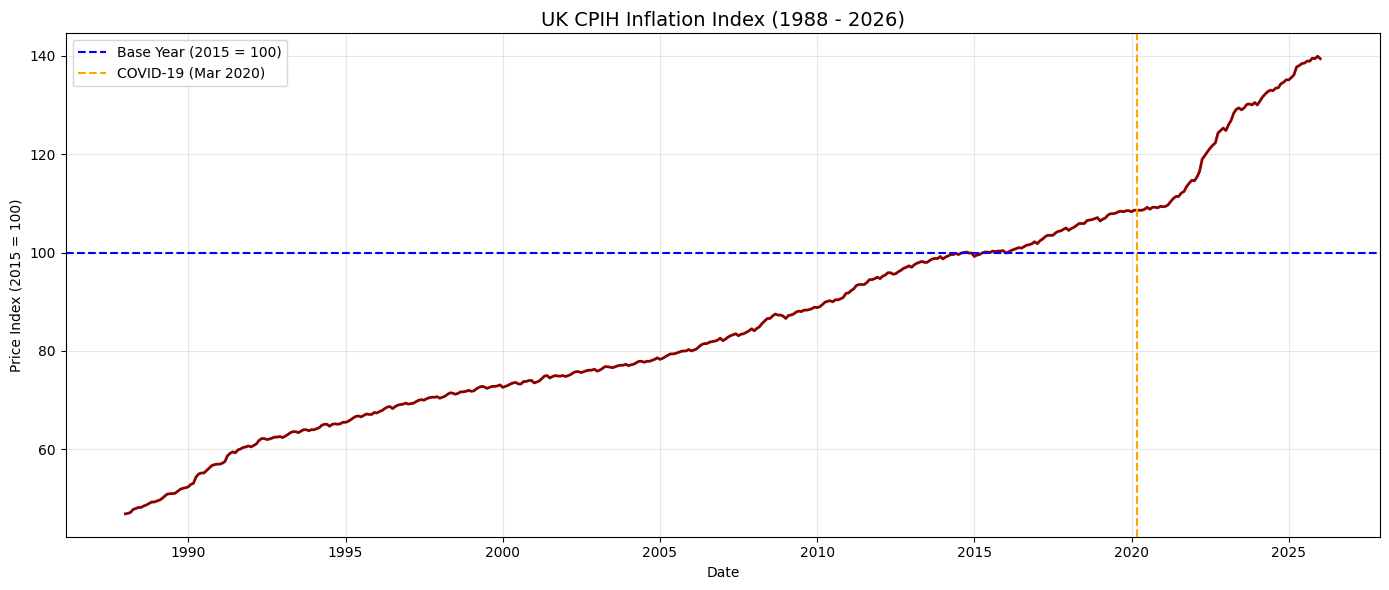

In [64]:
import matplotlib.pyplot as plt

# Sort by date properly
overall_cpih['date'] = pd.to_datetime(
    overall_cpih['mmm-yy'], 
    format='%b-%y'
)
overall_cpih_sorted = overall_cpih.sort_values('date')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    overall_cpih_sorted['date'], 
    overall_cpih_sorted['v4_0'],
    color='darkred',
    linewidth=2
)

# Add reference lines
plt.axhline(y=100, color='blue', linestyle='--', label='Base Year (2015 = 100)')
plt.axvline(
    pd.to_datetime('2020-03-01'), 
    color='orange', 
    linestyle='--', 
    label='COVID-19 (Mar 2020)'
)

plt.title('UK CPIH Inflation Index (1988 - 2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price Index (2015 = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [59]:
df2.head()

,v4_0,mmm-yy,Time,uk-only,Geography,cpih1dim1aggid,Aggregate
0,118.4,Jan-26,Jan-26,K02000001,United Kingdom,CP055,05.5 Tools and equipment for house and garden
1,132.5,Jan-26,Jan-26,K02000001,United Kingdom,CP061,"06.1 Medical products, appliances and equipment"
2,131.0,Jan-26,Jan-26,K02000001,United Kingdom,CP092,09.2 Other major durables for recreation and c...
3,124.5,Jan-26,Jan-26,K02000001,United Kingdom,CP093,"09.3 Other recreational items, gardens and pets"
4,160.0,Jan-26,Jan-26,K02000001,United Kingdom,CP096,09.6 Package holidays


In [9]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 434 entries, 0 to 433
Data columns (total 7 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Date                                                                434 non-null    str    
 1   ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre  434 non-null    float64
 2   ULSD (Ultra low sulphur diesel) Pump price in pence/litre           434 non-null    float64
 3   ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre   434 non-null    float64
 4   ULSD (Ultra low sulphur diesel) Duty rate in pence/litre            434 non-null    float64
 5   ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate        434 non-null    int64  
 6   ULSD (Ultra low sulphur diesel) VAT percentage rate                 434 non-null    int64  
dtypes: float64(4), int64(2), str(

In [10]:
df.dtypes

Date                                                                      str
ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre    float64
ULSD (Ultra low sulphur diesel) Pump price in pence/litre             float64
ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre     float64
ULSD (Ultra low sulphur diesel) Duty rate in pence/litre              float64
ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate            int64
ULSD (Ultra low sulphur diesel) VAT percentage rate                     int64
dtype: object

In [11]:
df.tail

<bound method NDFrame.tail of            Date  \
0    01/01/2018   
1    08/01/2018   
2    15/01/2018   
3    22/01/2018   
4    29/01/2018   
..          ...   
429  23/03/2026   
430  30/03/2026   
431  06/04/2026   
432  13/04/2026   
433  20/04/2026   

     ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre  \
0                                               120.19                    
1                                               120.52                    
2                                               120.96                    
3                                               121.50                    
4                                               121.69                    
..                                                 ...                    
429                                             144.16                    
430                                             148.78                    
431                                             154.65            

In [12]:
df.shape

(434, 7)

In [14]:
df.isnull().sum()

Date                                                                  0
ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre    0
ULSD (Ultra low sulphur diesel) Pump price in pence/litre             0
ULSP (Ultra low sulphur unleaded petrol) Duty rate in pence/litre     0
ULSD (Ultra low sulphur diesel) Duty rate in pence/litre              0
ULSP (Ultra low sulphur unleaded petrol) VAT percentage rate          0
ULSD (Ultra low sulphur diesel) VAT percentage rate                   0
dtype: int64

In [15]:
df.describe

<bound method NDFrame.describe of            Date  \
0    01/01/2018   
1    08/01/2018   
2    15/01/2018   
3    22/01/2018   
4    29/01/2018   
..          ...   
429  23/03/2026   
430  30/03/2026   
431  06/04/2026   
432  13/04/2026   
433  20/04/2026   

     ULSP (Ultra low sulphur unleaded petrol) Pump price in pence/litre  \
0                                               120.19                    
1                                               120.52                    
2                                               120.96                    
3                                               121.50                    
4                                               121.69                    
..                                                 ...                    
429                                             144.16                    
430                                             148.78                    
431                                             154.65        

In [28]:
import json
inflation_url = "https://api.beta.ons.gov.uk/v1/datasets"
response = requests.get(inflation_url)
data = response.json()
print(f"Type: {type(data)}")
print(f"Keys: {data.keys()}")
if 'items' in data:
    print(f"\nNumber of datasets: {len(data['items'])}")
    
    # Step 4: Look at first dataset
    print("\n--- First Dataset ---")
    print(json.dumps(data['items'][0], indent=2)) 

Type: <class 'dict'>
Keys: dict_keys(['items', 'count', 'offset', 'limit', 'total_count'])

Number of datasets: 20

--- First Dataset ---
{
  "contacts": [
    {
      "email": "qualityoflife@ons.gov.uk",
      "name": "Will Shufflebottom, Owain Birrell, Pavan Bains and Geeta Kerai",
      "telephone": "+44 300 0671543"
    }
  ],
  "description": "Seasonally and non seasonally-adjusted quarterly estimates of life satisfaction, feeling that the things done in life are worthwhile, happiness and anxiety in the UK.",
  "keywords": [
    "well-being"
  ],
  "id": "wellbeing-quarterly",
  "last_updated": "2023-12-13T09:40:24.204Z",
  "links": {
    "editions": {
      "href": "https://api.beta.ons.gov.uk/v1/datasets/wellbeing-quarterly/editions"
    },
    "latest_version": {
      "href": "https://api.beta.ons.gov.uk/v1/datasets/wellbeing-quarterly/editions/time-series/versions/9",
      "id": "9"
    },
    "self": {
      "href": "https://api.beta.ons.gov.uk/v1/datasets/wellbeing-quarter

In [32]:
import requests

url = "https://api.beta.ons.gov.uk/v1/datasets"
response = requests.get(url)
data = response.json()

print(f"Showing: {data['count']} datasets")
print(f"Total available: {data['total_count']} datasets")



Showing: 20 datasets
Total available: 337 datasets


In [33]:
import requests

# Get more datasets (increase limit)
url = "https://api.beta.ons.gov.uk/v1/datasets?limit=100"
response = requests.get(url)
data = response.json()

print(f"Now showing: {data['count']} datasets\n")

# Search again
print("🔍 Searching for inflation/price datasets...\n")

for item in data['items']:
    title = item.get('title', '').lower()
    description = item.get('description', '').lower()
    dataset_id = item.get('id', '')
    
    keywords = ['inflation', 'price', 'cpi', 'cpih', 'consumer']
    
    if any(word in title or word in description for word in keywords):
        print(f"📊 FOUND: {item.get('title')}")
        print(f"   ID: {dataset_id}")
        print()

Now showing: 100 datasets

🔍 Searching for inflation/price datasets...

📊 FOUND: Output in the construction industry
   ID: output-in-the-construction-industry

📊 FOUND: Index of Private Housing Rental Prices
   ID: index-private-housing-rental-prices

📊 FOUND: House price statistics for small areas in England and Wales
   ID: house-prices-local-authority

📊 FOUND: GVA by industry by local authority
   ID: gva-by-industry-by-local-authority

📊 FOUND: Generational income: The effects of taxes and benefits
   ID: generational-income

📊 FOUND: GDP by local authority
   ID: gdp-by-local-authority

📊 FOUND: Consumer Prices Index including owner occupiers' housing costs (CPIH)
   ID: cpih01



In [34]:
import requests
import json

# Get the CPIH dataset details
url = "https://api.beta.ons.gov.uk/v1/datasets/cpih01"
response = requests.get(url)
data = response.json()

print("📊 CPIH Dataset Info:")
print(f"Title: {data.get('title')}")
print(f"Description: {data.get('description', '')[:200]}...")
print(f"\nAvailable links:")
print(json.dumps(data.get('links', {}), indent=2))

📊 CPIH Dataset Info:
Title: Consumer Prices Index including owner occupiers' housing costs (CPIH)
Description: CPIH is the most comprehensive measure of inflation. It extends CPI to include a measure of the costs associated with owning, maintaining and living in one's own home, known as owner occupiers' housin...

Available links:
{
  "editions": {
    "href": "https://api.beta.ons.gov.uk/v1/datasets/cpih01/editions"
  },
  "latest_version": {
    "href": "https://api.beta.ons.gov.uk/v1/datasets/cpih01/editions/time-series/versions/67",
    "id": "67"
  },
  "self": {
    "href": "https://api.beta.ons.gov.uk/v1/datasets/cpih01"
  },
  "taxonomy": {
    "href": "https://api.beta.ons.gov.uk/v1/economy/inflationandpriceindices"
  }
}


In [35]:
import requests
import json

# Get latest version details
url = "https://api.beta.ons.gov.uk/v1/datasets/cpih01/editions/time-series/versions/67"
response = requests.get(url)
data = response.json()

print("📊 Latest Version Info:")
print(f"Release date: {data.get('release_date')}")
print(f"State: {data.get('state')}")
print(f"\nAvailable links:")
print(json.dumps(data.get('links', {}), indent=2))

# Look for download links
print("\n📥 Download options:")
print(json.dumps(data.get('downloads', {}), indent=2))

📊 Latest Version Info:
Release date: 2026-02-18T00:00:00.000Z
State: published

Available links:
{
  "dataset": {
    "href": "https://api.beta.ons.gov.uk/v1/datasets/cpih01",
    "id": "cpih01"
  },
  "dimensions": {},
  "edition": {
    "href": "https://api.beta.ons.gov.uk/v1/datasets/cpih01/editions/time-series",
    "id": "time-series"
  },
  "self": {
    "href": "https://api.beta.ons.gov.uk/v1/datasets/cpih01/editions/time-series/versions/67"
  }
}

📥 Download options:
{
  "xls": {
    "href": "https://download.ons.gov.uk/downloads/datasets/cpih01/editions/time-series/versions/67.xlsx",
    "size": "285345"
  },
  "csv": {
    "href": "https://download.ons.gov.uk/downloads/datasets/cpih01/editions/time-series/versions/67.csv",
    "size": "4702653"
  },
  "csvw": {
    "href": "https://download.ons.gov.uk/downloads/datasets/cpih01/editions/time-series/versions/67.csv-metadata.json",
    "size": "1600"
  }
}
